## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## Data Preprocessing

In [2]:
import pandas as pd
file_path="../data/raw/nino34_oni.txt"
with open(file_path, 'r',encoding='utf-8') as f:
    lines=f.readlines()
print("total lines:",len(lines))
for line in lines[:10]:
    print(line.rstrip())
for line in lines[-10:]:
    print(line.rstrip())


total lines: 918
 SEAS  YR   TOTAL   ANOM
  DJF 1950  24.72  -1.53
  JFM 1950  25.17  -1.34
  FMA 1950  25.75  -1.16
  MAM 1950  26.12  -1.18
  AMJ 1950  26.32  -1.07
  MJJ 1950  26.31  -0.85
  JJA 1950  26.21  -0.54
  JAS 1950  25.96  -0.42
  ASO 1950  25.76  -0.39
  JAS 2025  26.63  -0.28
  ASO 2025  26.32  -0.40
  SON 2025  26.16  -0.51
  OND 2025  26.05  -0.55
  NDJ 2025  25.97  -0.54
  DJF 2026  26.13  -0.37
  JFM 2026  26.58  -0.14
  FMA 2026  27.30   0.13
  MAM 2026  28.08   0.51
  AMJ 2026  28.71   0.98


In [3]:
oni = pd.read_csv("../data/raw/nino34_oni.txt", sep=r"\s+")
oni.columns = oni.columns.str.strip()
oni.head()

,SEAS,YR,TOTAL,ANOM
0,DJF,1950,24.72,-1.53
1,JFM,1950,25.17,-1.34
2,FMA,1950,25.75,-1.16
3,MAM,1950,26.12,-1.18
4,AMJ,1950,26.32,-1.07


In [4]:
rain = pd.read_csv("../data/raw/Sub_Division_IMD_2017.csv")
rain.columns = rain.columns.str.strip()
print(rain.shape)
rain.head()

(4188, 19)


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [5]:
print("Year range:", rain["YEAR"].min(), "-", rain["YEAR"].max())
print("Unique subdivisions:", rain["SUBDIVISION"].nunique())

for name, group in rain.groupby("SUBDIVISION"):
    years = group["YEAR"].sort_values()
    diffs = years.diff()
    gaps = years[diffs > 1]
    if len(gaps) > 0:
        print(f"{name}: missing year(s) before {list(gaps.values)}")


Year range: 1901 - 2017
Unique subdivisions: 36
Andaman & Nicobar Islands: missing year(s) before [np.int64(1910), np.int64(1946), np.int64(1949)]
Arunachal Pradesh: missing year(s) before [np.int64(1957)]
Lakshadweep: missing year(s) before [np.int64(1919)]


In [6]:
soi = pd.read_fwf(
    "../data/raw/soi.txt",
    skiprows=88,
    widths=[4] + [6] * 12,
    names=["YEAR", "JAN", "FEB", "MAR", "APR", "MAY", "JUN",
           "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"],
)
soi = soi.apply(pd.to_numeric, errors="coerce")
soi = soi.replace(-999.9, np.nan)
soi = soi.dropna(how="all", subset=soi.columns[1:])
print(soi.shape)
soi.head()
soi.tail()

soi_spring = soi[["YEAR", "MAR", "APR", "MAY"]].copy()
soi_spring["spring_soi"] = soi_spring[["MAR", "APR", "MAY"]].mean(axis=1)
soi_spring = soi_spring[["YEAR", "spring_soi"]].dropna()
soi_spring.head()


(76, 13)


,YEAR,spring_soi
0,1951,-0.366667
1,1952,0.366667
2,1953,-0.566667
3,1954,0.466667
4,1955,0.500000


In [7]:
dmi_raw = pd.read_csv(
    "../data/raw/dmi_iod.txt",
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["YEAR", "JAN", "FEB", "MAR", "APR", "MAY", "JUN",
           "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"],
)
dmi_raw["YEAR"] = pd.to_numeric(dmi_raw["YEAR"], errors="coerce")
dmi_raw = dmi_raw[dmi_raw["YEAR"].between(1870, 2030)].copy()
month_cols = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
dmi_raw[month_cols] = dmi_raw[month_cols].apply(pd.to_numeric, errors="coerce")
dmi_raw["YEAR"] = dmi_raw["YEAR"].astype(int)
dmi_raw = dmi_raw.replace(-9999.0, np.nan)

dmi_spring = dmi_raw[["YEAR", "MAR", "APR", "MAY"]].copy()
dmi_spring["spring_iod"] = dmi_spring[["MAR", "APR", "MAY"]].mean(axis=1)
dmi_spring = dmi_spring[["YEAR", "spring_iod"]].dropna()
dmi_spring.head()


,YEAR,spring_iod
0,1870,-0.117000
1,1871,-0.158333
2,1872,-0.102000
3,1873,-0.362333
4,1874,-0.593333


In [8]:
aismr = pd.read_csv(
    "../data/raw/iitm_aismr.txt",
    sep=r"\s+",
    skiprows=5,
    names=["YEAR", "pct_departure_national"],
)
aismr = aismr.apply(pd.to_numeric, errors="coerce").dropna()
print(aismr.shape)
aismr.head()


(149, 2)


,YEAR,pct_departure_national
0,1871,-0.40
1,1872,7.21
2,1873,-11.14
3,1874,14.34
4,1875,9.10


## Feature Engineering

In [9]:
oni_spring = oni[oni["SEAS"] == "MAM"][["YR", "ANOM"]].copy()
oni_spring = oni_spring.rename(columns={"YR": "YEAR", "ANOM": "spring_oni"})
oni_spring.head()

,YEAR,spring_oni
3,1950,-1.18
15,1951,0.18
27,1952,0.29
39,1953,0.66
51,1954,-0.41


In [10]:
df = oni_spring.merge(dmi_spring, on="YEAR", how="left").merge(soi_spring, on="YEAR", how="left")
print(df.shape)
df.head()


(77, 4)


,YEAR,spring_oni,spring_iod,spring_soi
0,1950,-1.18,-0.491667,NaN
1,1951,0.18,-0.131000,-0.366667
2,1952,0.29,0.017333,0.366667
3,1953,0.66,0.150000,-0.566667
4,1954,-0.41,-0.240667,0.466667


In [11]:
national_df = df.merge(aismr, on="YEAR", how="inner")
print(national_df.shape)
national_df.head()


(70, 5)


,YEAR,spring_oni,spring_iod,spring_soi,pct_departure_national
0,1950,-1.18,-0.491667,NaN,2.91
1,1951,0.18,-0.131000,-0.366667,-13.31
2,1952,0.29,0.017333,0.366667,-6.97
3,1953,0.66,0.150000,-0.566667,8.30
4,1954,-0.41,-0.240667,0.466667,3.88


In [12]:
national_df.to_csv("../data/processed/national_df.csv", index=False)


In [13]:
rain_reduced = rain[["SUBDIVISION", "YEAR", "JJAS"]].copy()
clim = rain_reduced.groupby("SUBDIVISION")["JJAS"].transform("mean")
rain_reduced["jjas_pct_departure"] = (rain_reduced["JJAS"] - clim) / clim * 100

regional_df = rain_reduced.merge(df, on="YEAR", how="inner")
print("regional_df shape:", regional_df.shape)
regional_df.to_csv("../data/processed/regional_df.csv", index=False)

results = []
for name, group in regional_df.groupby("SUBDIVISION"):
    g = group.dropna(subset=["spring_oni", "spring_iod", "spring_soi", "jjas_pct_departure"])
    if len(g) < 10:
        continue
    results.append((
        name,
        g["spring_oni"].corr(g["jjas_pct_departure"]),
        g["spring_iod"].corr(g["jjas_pct_departure"]),
        g["spring_soi"].corr(g["jjas_pct_departure"]),
    ))

corr_by_subdivision = pd.DataFrame(results, columns=["SUBDIVISION", "corr_oni", "corr_iod", "corr_soi"])
corr_by_subdivision["max_abs_corr"] = corr_by_subdivision[["corr_oni", "corr_iod", "corr_soi"]].abs().max(axis=1)
corr_by_subdivision.sort_values("max_abs_corr", ascending=False).head(10)


regional_df shape: (2445, 7)


,SUBDIVISION,corr_oni,corr_iod,corr_soi,max_abs_corr
1,Arunachal Pradesh,0.206407,-0.374626,-0.052821,0.374626
31,Uttarakhand,-0.208300,-0.170415,0.357107,0.357107
30,Telangana,0.051125,-0.327357,0.066442,0.327357
35,West Uttar Pradesh,-0.018128,-0.289841,0.150234,0.289841
20,Matathwada,0.109138,-0.281314,0.100325,0.281314
24,Punjab,-0.188856,-0.209834,0.269023,0.269023
3,Bihar,-0.267608,0.019309,0.079004,0.267608
9,East Uttar Pradesh,-0.253641,-0.133243,0.250292,0.253641
10,Gangetic West Bengal,-0.237223,0.115629,0.099828,0.237223
32,Vidarbha,0.064240,-0.236410,0.018320,0.236410


## Exploratory Correlation Analysis

In [14]:
corr_table=national_df[["spring_oni", "spring_iod", "spring_soi", "pct_departure_national"]].corr()

print(corr_table.sort_values(by="pct_departure_national", key=abs, ascending=False))


                        spring_oni  spring_iod  spring_soi  \
pct_departure_national   -0.114828   -0.111241    0.165876   
spring_soi               -0.782030   -0.062205    1.000000   
spring_oni                1.000000   -0.011021   -0.782030   
spring_iod               -0.011021    1.000000   -0.062205   

                        pct_departure_national  
pct_departure_national                1.000000  
spring_soi                            0.165876  
spring_oni                           -0.114828  
spring_iod                           -0.111241  


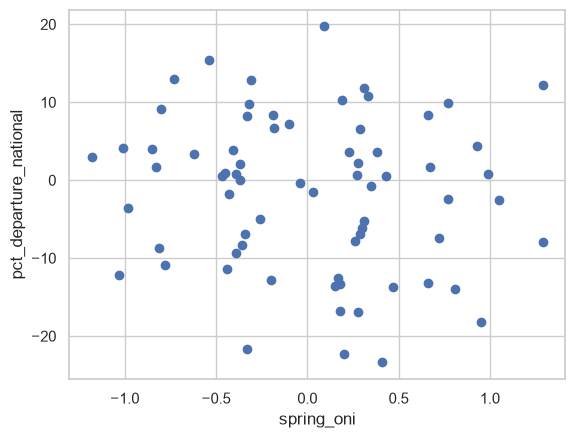

In [15]:
plt.scatter(national_df["spring_oni"], national_df["pct_departure_national"])
plt.xlabel("spring_oni")
plt.ylabel("pct_departure_national")
plt.show()


## Model Training and Evaluation - National

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut

model_df = national_df.dropna(subset=["spring_oni", "spring_iod", "spring_soi", "pct_departure_national"]).reset_index(drop=True)
print("rows used:", len(model_df))

X = model_df[["spring_oni", "spring_iod", "spring_soi"]].values
y = model_df["pct_departure_national"].values

loo = LeaveOneOut()
baseline_preds, model_preds, actuals = [], [], []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    baseline_preds.append(y_train.mean())

    reg = LinearRegression().fit(X_train, y_train)
    model_preds.append(reg.predict(X_test)[0])

    actuals.append(y_test[0])

actuals = np.array(actuals)
baseline_preds = np.array(baseline_preds)
model_preds = np.array(model_preds)

baseline_rmse = np.sqrt(np.mean((actuals - baseline_preds) ** 2))
model_rmse = np.sqrt(np.mean((actuals - model_preds) ** 2))

print("Climatology baseline RMSE:", round(baseline_rmse, 3))
print("Linear regression RMSE:", round(model_rmse, 3))


rows used: 69
Climatology baseline RMSE: 9.989
Linear regression RMSE: 10.245


In [17]:

from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestRegressor

model_df = national_df.dropna(subset=["spring_oni", "spring_iod", "spring_soi", "pct_departure_national"]).reset_index(drop=True)
print("rows used:", len(model_df))

X = model_df[["spring_oni", "spring_iod", "spring_soi"]].values
y = model_df["pct_departure_national"].values

loo = LeaveOneOut()
baseline_preds, model_preds, actuals = [], [], []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    baseline_preds.append(y_train.mean())

    reg = RandomForestRegressor(max_depth=4, n_estimators=100, random_state=42)
    reg.fit(X_train, y_train)
    model_preds.append(reg.predict(X_test)[0])

    actuals.append(y_test[0])

actuals = np.array(actuals)
baseline_preds = np.array(baseline_preds)
model_preds = np.array(model_preds)

baseline_rmse = np.sqrt(np.mean((actuals - baseline_preds) ** 2))
model_rmse = np.sqrt(np.mean((actuals - model_preds) ** 2))

print("Climatology baseline RMSE:", round(baseline_rmse, 3))
print("random forest  regression RMSE:", round(model_rmse, 3))


rows used: 69
Climatology baseline RMSE: 9.989
random forest  regression RMSE: 10.981


In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

d_sarimax = national_df.dropna(subset=["spring_oni", "spring_iod", "spring_soi", "pct_departure_national"]).sort_values("YEAR").reset_index(drop=True)
y_s = d_sarimax["pct_departure_national"].values
X_s = d_sarimax[["spring_oni", "spring_iod", "spring_soi"]].values

min_train = 20
sarimax_baseline_preds, sarimax_model_preds, sarimax_actuals = [], [], []

for t in range(min_train, len(d_sarimax)):
    y_train, X_train = y_s[:t], X_s[:t]
    y_test, X_test = y_s[t], X_s[t:t + 1]
    sarimax_baseline_preds.append(y_train.mean())
    try:
        sarimax_model = SARIMAX(y_train, exog=X_train, order=(1, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
        sarimax_fit = sarimax_model.fit(disp=False)
        pred = sarimax_fit.forecast(steps=1, exog=X_test)[0]
    except Exception:
        pred = y_train.mean()
    sarimax_model_preds.append(pred)
    sarimax_actuals.append(y_test)

sarimax_actuals = np.array(sarimax_actuals)
sarimax_baseline_preds = np.array(sarimax_baseline_preds)
sarimax_model_preds = np.array(sarimax_model_preds)

sarimax_baseline_rmse = np.sqrt(np.mean((sarimax_actuals - sarimax_baseline_preds) ** 2))
sarimax_rmse = np.sqrt(np.mean((sarimax_actuals - sarimax_model_preds) ** 2))

print("SARIMAX evaluated via walk-forward validation (not leave-one-year-out,")
print("since ARIMA-family models require unbroken chronological order):")
print("Walk-forward baseline RMSE:", round(sarimax_baseline_rmse, 3))
print("SARIMAX(1,0,0) + ENSO/IOD/SOI RMSE:", round(sarimax_rmse, 3))


SARIMAX evaluated via walk-forward validation (not leave-one-year-out,
since ARIMA-family models require unbroken chronological order):
Walk-forward baseline RMSE: 9.921
SARIMAX(1,0,0) + ENSO/IOD/SOI RMSE: 10.492


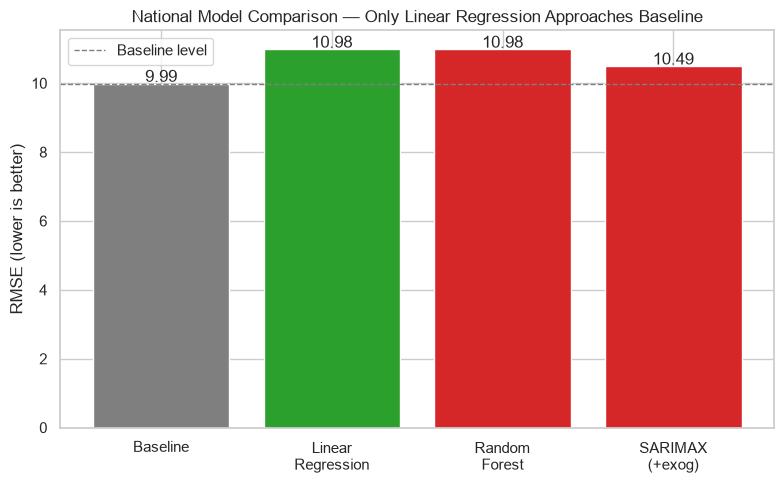

In [19]:
approaches = ["Baseline", "Linear\nRegression", "Random\nForest", "SARIMAX\n(+exog)"]
rmses = [baseline_rmse, model_rmse, 10.981, sarimax_rmse]
colors = ["#7f7f7f", "#2ca02c", "#d62728", "#d62728"]

plt.figure(figsize=(8, 5))
bars = plt.bar(approaches, rmses, color=colors)
plt.axhline(baseline_rmse, color="#7f7f7f", linestyle="--", linewidth=1, label="Baseline level")
plt.ylabel("RMSE (lower is better)")
plt.title("National Model Comparison — Only Linear Regression Approaches Baseline")
for bar, val in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.05, f"{val:.2f}", ha="center")
plt.legend()
plt.tight_layout()
plt.show()


## Model Training and Evaluation - Regional

In [20]:
sub = regional_df[regional_df["SUBDIVISION"] == "Arunachal Pradesh"].dropna(
    subset=["spring_oni", "spring_iod", "spring_soi", "jjas_pct_departure"]
).reset_index(drop=True)
print("rows:", len(sub))

X = sub[["spring_oni", "spring_iod", "spring_soi"]].values
y = sub["jjas_pct_departure"].values

loo = LeaveOneOut()
baseline_preds, model_preds, actuals = [], [], []
for train_idx, test_idx in loo.split(X):
    baseline_preds.append(y[train_idx].mean())
    reg = LinearRegression().fit(X[train_idx], y[train_idx])
    model_preds.append(reg.predict(X[test_idx])[0])
    actuals.append(y[test_idx][0])

actuals = np.array(actuals)
baseline_preds = np.array(baseline_preds)
model_preds = np.array(model_preds)

print("baseline RMSE:", round(np.sqrt(np.mean((actuals - baseline_preds) ** 2)), 3))
print("linear reg RMSE:", round(np.sqrt(np.mean((actuals - model_preds) ** 2)), 3))


rows: 64
baseline RMSE: 27.787
linear reg RMSE: 26.455


In [21]:
results = []
for name, group in regional_df.groupby("SUBDIVISION"):
    g = group.dropna(subset=["spring_oni", "spring_iod", "spring_soi", "jjas_pct_departure"]).reset_index(drop=True)
    if len(g) < 20:
        continue
    X = g[["spring_oni", "spring_iod", "spring_soi"]].values
    y = g["jjas_pct_departure"].values
    loo = LeaveOneOut()
    baseline_preds, model_preds, actuals = [], [], []
    for train_idx, test_idx in loo.split(X):
        baseline_preds.append(y[train_idx].mean())
        reg = LinearRegression().fit(X[train_idx], y[train_idx])
        model_preds.append(reg.predict(X[test_idx])[0])
        actuals.append(y[test_idx][0])
    actuals = np.array(actuals)
    baseline_preds = np.array(baseline_preds)
    model_preds = np.array(model_preds)
    baseline_rmse = np.sqrt(np.mean((actuals - baseline_preds) ** 2))
    model_rmse = np.sqrt(np.mean((actuals - model_preds) ** 2))
    results.append((name, len(g), baseline_rmse, model_rmse, baseline_rmse - model_rmse))

subdivision_results = pd.DataFrame(results, columns=["SUBDIVISION", "n", "baseline_rmse", "model_rmse", "improvement"])
subdivision_results = subdivision_results.sort_values("improvement", ascending=False)
print("subdivisions where model beats baseline:", (subdivision_results["improvement"] > 0).sum(), "of", len(subdivision_results))
subdivision_results.to_csv("../data/processed/subdivision_model_results.csv", index=False)
subdivision_results


subdivisions where model beats baseline: 10 of 36


,SUBDIVISION,n,baseline_rmse,model_rmse,improvement
1,Arunachal Pradesh,64,27.787427,26.454853,1.332574
31,Uttarakhand,67,19.508220,18.675826,0.832394
20,Matathwada,67,26.100239,25.398866,0.701373
24,Punjab,67,32.782001,32.089108,0.692893
35,West Uttar Pradesh,67,25.245089,24.791885,0.453204
30,Telangana,67,24.454748,24.169407,0.285341
9,East Uttar Pradesh,67,22.851045,22.626967,0.224078
8,East Rajasthan,67,23.149826,23.031427,0.118399
3,Bihar,67,17.520779,17.427245,0.093534
17,Konkan & Goa,67,16.414678,16.387219,0.027459


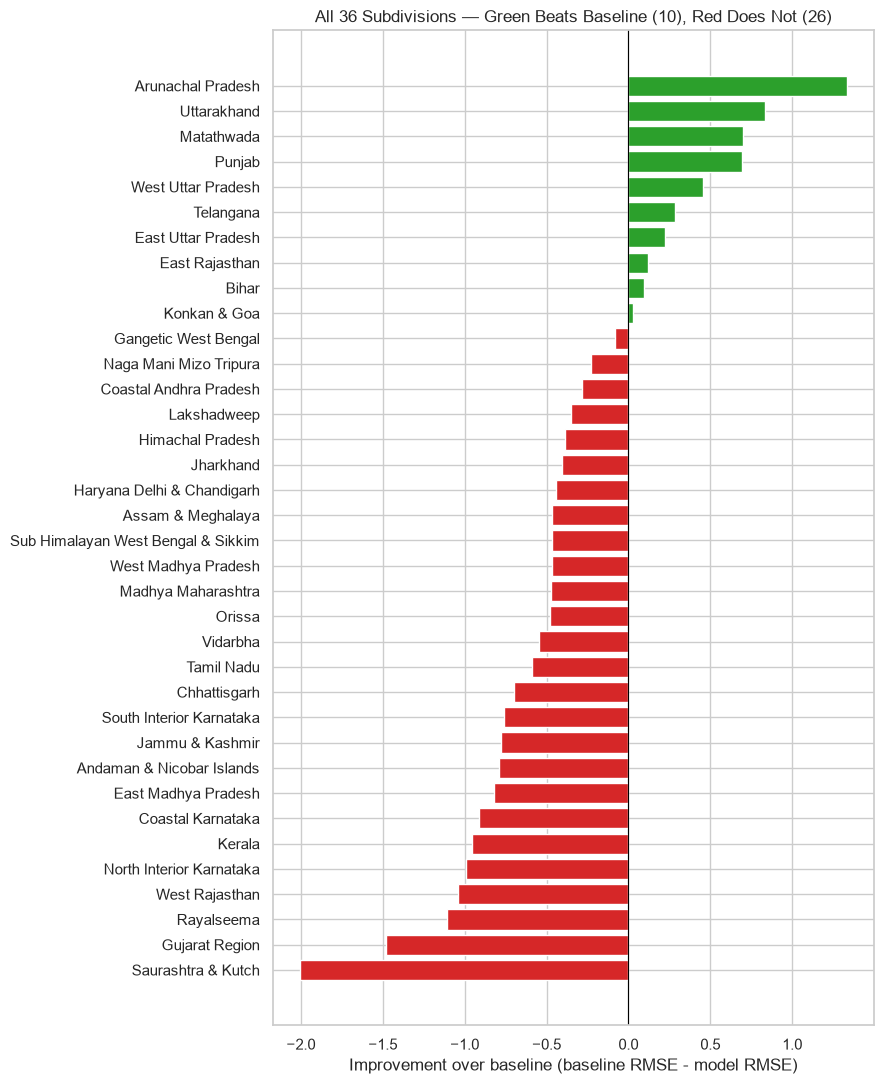

In [22]:
plot_df = subdivision_results.sort_values("improvement", ascending=True)
bar_colors = ["#2ca02c" if v > 0 else "#d62728" for v in plot_df["improvement"]]

plt.figure(figsize=(9, 11))
plt.barh(plot_df["SUBDIVISION"], plot_df["improvement"], color=bar_colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Improvement over baseline (baseline RMSE - model RMSE)")
plt.title("All 36 Subdivisions — Green Beats Baseline (10), Red Does Not (26)")
plt.tight_layout()
plt.show()


## Disaster Risk Flagging

In [23]:
def risk_band(pct_dep):
    if pct_dep <= -10:
        return "Deficient (drought risk)"
    elif pct_dep >= 10:
        return "Excess (flood risk)"
    else:
        return "Normal"

regional_df["risk_flag"] = regional_df["jjas_pct_departure"].apply(risk_band)
regional_df.to_csv("../data/processed/regional_df.csv", index=False)
regional_df["risk_flag"].value_counts()


risk_flag
Normal                      889
Deficient (drought risk)    824
Excess (flood risk)         732
Name: count, dtype: int64

## Regional Zone Summary (North South East West)

In [24]:
SUBDIVISION_ZONE = {
    "Jammu & Kashmir": "North", "Himachal Pradesh": "North", "Punjab": "North",
    "Haryana Delhi & Chandigarh": "North", "Uttarakhand": "North",
    "West Uttar Pradesh": "North", "East Uttar Pradesh": "North",
    "Coastal Andhra Pradesh": "South", "Rayalseema": "South", "Telangana": "South",
    "Tamil Nadu": "South", "Kerala": "South", "Coastal Karnataka": "South",
    "North Interior Karnataka": "South", "South Interior Karnataka": "South",
    "Lakshadweep": "South",
    "Bihar": "East", "Jharkhand": "East", "Orissa": "East",
    "Gangetic West Bengal": "East", "Sub Himalayan West Bengal & Sikkim": "East",
    "Arunachal Pradesh": "East", "Assam & Meghalaya": "East",
    "Naga Mani Mizo Tripura": "East", "Andaman & Nicobar Islands": "East",
    "Gujarat Region": "West", "Saurashtra & Kutch": "West", "Konkan & Goa": "West",
    "Madhya Maharashtra": "West", "Matathwada": "West", "Vidarbha": "West",
    "West Rajasthan": "West", "East Rajasthan": "West",
    "East Madhya Pradesh": "West", "West Madhya Pradesh": "West", "Chhattisgarh": "West",
}
regional_df["zone"] = regional_df["SUBDIVISION"].map(SUBDIVISION_ZONE)
regional_df.to_csv("../data/processed/regional_df.csv", index=False)

zone_summary = regional_df.groupby("zone").agg(
    avg_jjas_pct_departure=("jjas_pct_departure", "mean"),
    pct_deficient_years=("risk_flag", lambda x: (x.str.contains("Deficient")).mean() * 100),
    pct_excess_years=("risk_flag", lambda x: (x.str.contains("Excess")).mean() * 100),
    n_subdivisions=("SUBDIVISION", "nunique"),
).reset_index()
zone_summary.to_csv("../data/processed/zone_summary.csv", index=False)
zone_summary


,zone,avg_jjas_pct_departure,pct_deficient_years,pct_excess_years,n_subdivisions
0,East,-3.572789,37.274220,20.361248,9
1,North,-0.543677,36.554622,31.932773,7
2,South,2.306554,27.941176,33.823529,9
3,West,0.749559,33.689840,33.288770,11


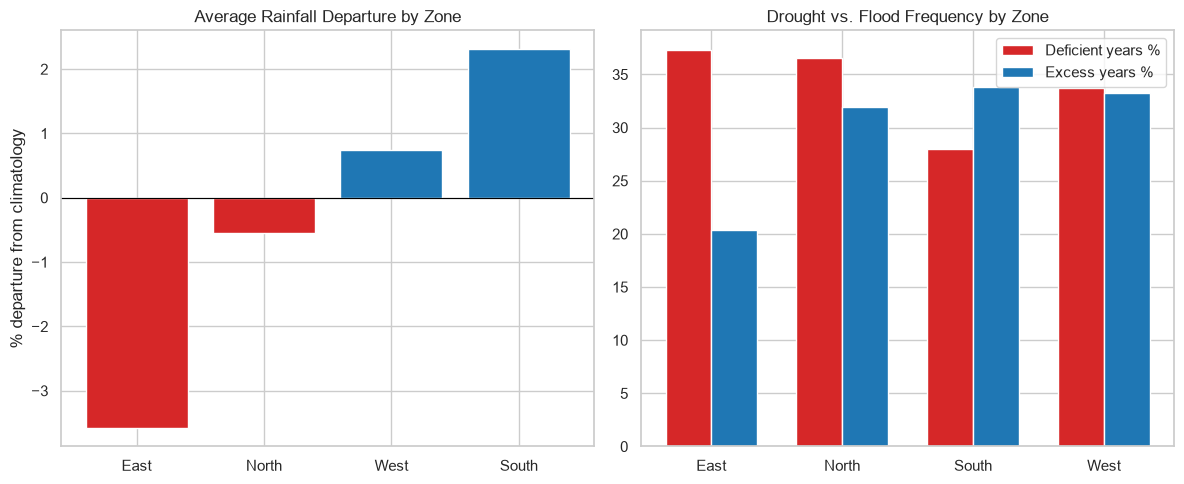

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

zone_order = zone_summary.sort_values("avg_jjas_pct_departure")
axes[0].bar(zone_order["zone"], zone_order["avg_jjas_pct_departure"], color=["#d62728" if v < 0 else "#1f77b4" for v in zone_order["avg_jjas_pct_departure"]])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Average Rainfall Departure by Zone")
axes[0].set_ylabel("% departure from climatology")

x = np.arange(len(zone_summary))
width = 0.35
axes[1].bar(x - width / 2, zone_summary["pct_deficient_years"], width, label="Deficient years %", color="#d62728")
axes[1].bar(x + width / 2, zone_summary["pct_excess_years"], width, label="Excess years %", color="#1f77b4")
axes[1].set_xticks(x)
axes[1].set_xticklabels(zone_summary["zone"])
axes[1].set_title("Drought vs. Flood Frequency by Zone")
axes[1].legend()

plt.tight_layout()
plt.show()


## Final Models and 2026 Forecast

In [26]:
import joblib
import os

skilled_subdivisions = subdivision_results[subdivision_results["improvement"] > 0]["SUBDIVISION"].tolist()
print("Subdivisions getting a final model:", len(skilled_subdivisions))

os.makedirs("../models", exist_ok=True)

for name in skilled_subdivisions:
    g = regional_df[regional_df["SUBDIVISION"] == name].dropna(
        subset=["spring_oni", "spring_iod", "spring_soi", "jjas_pct_departure"]
    )
    X = g[["spring_oni", "spring_iod", "spring_soi"]].values
    y = g["jjas_pct_departure"].values
    final_model = LinearRegression().fit(X, y)
    fname = name.replace(" ", "_").replace("&", "and")
    joblib.dump(final_model, f"../models/{fname}_final_model.pkl")

print("Saved:", os.listdir("../models"))


Subdivisions getting a final model: 10
Saved: ['Arunachal_Pradesh_final_model.pkl', 'Konkan_and_Goa_final_model.pkl', 'East_Rajasthan_final_model.pkl', 'East_Uttar_Pradesh_final_model.pkl', 'monthly', 'Punjab_final_model.pkl', 'Bihar_final_model.pkl', 'Telangana_final_model.pkl', 'West_Uttar_Pradesh_final_model.pkl', 'National_DJF_ONI_model.pkl', 'Matathwada_final_model.pkl', 'Uttarakhand_final_model.pkl']


In [27]:
X_2026 = [[0.51, 0.236667, -0.1]]

forecast_results = []
for name in skilled_subdivisions:
    fname = name.replace(" ", "_").replace("&", "and")
    model = joblib.load(f"../models/{fname}_final_model.pkl")
    pred = model.predict(X_2026)[0]
    forecast_results.append((name, round(pred, 2), risk_band(pred)))

forecast_2026 = pd.DataFrame(forecast_results, columns=["SUBDIVISION", "predicted_2026_pct_departure", "risk_flag"])
forecast_2026 = forecast_2026.sort_values("predicted_2026_pct_departure")
forecast_2026.to_csv("../data/processed/forecast_2026.csv", index=False)
forecast_2026


,SUBDIVISION,predicted_2026_pct_departure,risk_flag
0,Arunachal Pradesh,-26.66,Deficient (drought risk)
6,East Uttar Pradesh,-13.76,Deficient (drought risk)
3,Punjab,-11.87,Deficient (drought risk)
4,West Uttar Pradesh,-10.77,Deficient (drought risk)
8,Bihar,-9.98,Normal
1,Uttarakhand,-8.42,Normal
5,Telangana,-5.81,Normal
2,Matathwada,-4.05,Normal
7,East Rajasthan,0.02,Normal
9,Konkan & Goa,5.75,Normal


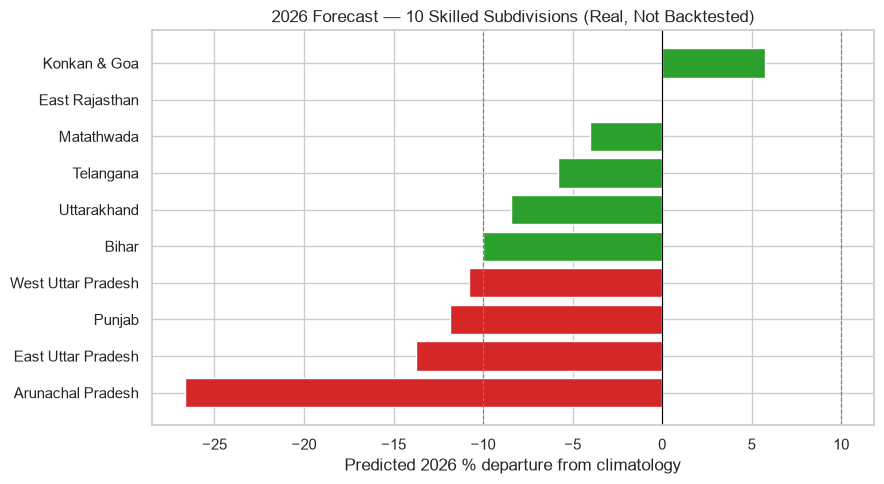

In [28]:
risk_colors = {"Deficient (drought risk)": "#d62728", "Excess (flood risk)": "#1f77b4", "Normal": "#2ca02c"}
bar_colors_2026 = forecast_2026["risk_flag"].map(risk_colors)

plt.figure(figsize=(9, 5))
plt.barh(forecast_2026["SUBDIVISION"], forecast_2026["predicted_2026_pct_departure"], color=bar_colors_2026)
plt.axvline(0, color="black", linewidth=0.8)
plt.axvline(-10, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(10, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Predicted 2026 % departure from climatology")
plt.title("2026 Forecast — 10 Skilled Subdivisions (Real, Not Backtested)")
plt.tight_layout()
plt.show()


## Monthly Breakdown Forecast

In [29]:
os.makedirs("../models/monthly", exist_ok=True)
monthly_results = []
monthly_forecast_rows = []

for month in ["JUN", "JUL", "AUG", "SEP"]:
    rain_month = rain[["SUBDIVISION", "YEAR", month]].copy()
    clim_month = rain_month.groupby("SUBDIVISION")[month].transform("mean")
    rain_month["pct_dep"] = (rain_month[month] - clim_month) / clim_month * 100
    merged_month = rain_month.merge(df, on="YEAR", how="inner")

    for name, group in merged_month.groupby("SUBDIVISION"):
        g = group.dropna(subset=["spring_oni", "spring_iod", "spring_soi", "pct_dep"]).reset_index(drop=True)
        if len(g) < 20:
            continue
        X = g[["spring_oni", "spring_iod", "spring_soi"]].values
        y = g["pct_dep"].values
        loo = LeaveOneOut()
        bp, mp, ac = [], [], []
        for train_idx, test_idx in loo.split(X):
            bp.append(y[train_idx].mean())
            reg = LinearRegression().fit(X[train_idx], y[train_idx])
            mp.append(reg.predict(X[test_idx])[0])
            ac.append(y[test_idx][0])
        ac, bp, mp = np.array(ac), np.array(bp), np.array(mp)
        b_rmse = np.sqrt(np.mean((ac - bp) ** 2))
        m_rmse = np.sqrt(np.mean((ac - mp) ** 2))
        monthly_results.append((month, name, len(g), b_rmse, m_rmse, b_rmse - m_rmse))

        if b_rmse - m_rmse > 0:
            final_month_model = LinearRegression().fit(X, y)
            fname = name.replace(" ", "_").replace("&", "and")
            joblib.dump(final_month_model, f"../models/monthly/{month}_{fname}_model.pkl")
            pred_2026_month = final_month_model.predict(X_2026)[0]
            monthly_forecast_rows.append((month, name, round(pred_2026_month, 2), risk_band(pred_2026_month)))

monthly_model_results = pd.DataFrame(monthly_results, columns=["month", "SUBDIVISION", "n", "baseline_rmse", "model_rmse", "improvement"])
monthly_model_results.to_csv("../data/processed/monthly_model_results.csv", index=False)

monthly_forecast_2026 = pd.DataFrame(monthly_forecast_rows, columns=["month", "SUBDIVISION", "predicted_pct_departure", "risk_flag"])
monthly_forecast_2026.to_csv("../data/processed/monthly_forecast_2026.csv", index=False)

print("Subdivision-month combinations beating baseline:", (monthly_model_results["improvement"] > 0).sum(), "of", len(monthly_model_results))
monthly_forecast_2026.sort_values(["SUBDIVISION", "month"])


Subdivision-month combinations beating baseline: 27 of 144


,month,SUBDIVISION,predicted_pct_departure,risk_flag
12,JUL,Arunachal Pradesh,-39.06,Deficient (drought risk)
0,JUN,Arunachal Pradesh,-31.13,Deficient (drought risk)
24,SEP,Arunachal Pradesh,-23.28,Deficient (drought risk)
13,JUL,Assam & Meghalaya,-13.16,Deficient (drought risk)
14,JUL,Bihar,-15.97,Deficient (drought risk)
1,JUN,Bihar,-13.44,Deficient (drought risk)
2,JUN,East Madhya Pradesh,-12.77,Deficient (drought risk)
3,JUN,East Uttar Pradesh,-15.06,Deficient (drought risk)
4,JUN,Haryana Delhi & Chandigarh,10.07,Excess (flood risk)
15,JUL,Himachal Pradesh,-18.75,Deficient (drought risk)


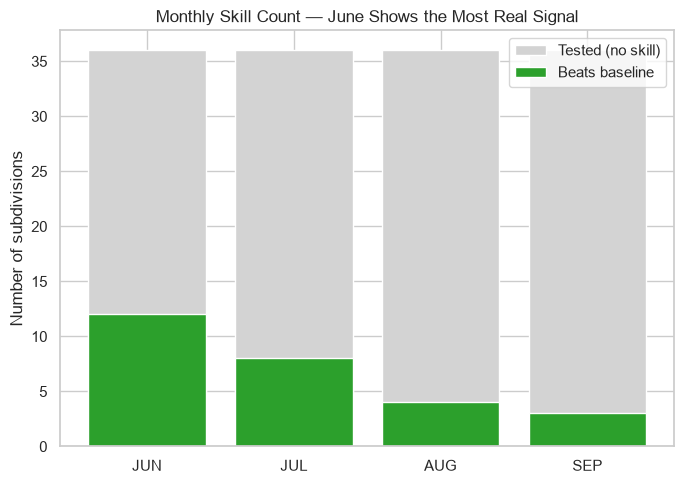

In [30]:
skilled_by_month = monthly_model_results[monthly_model_results["improvement"] > 0]["month"].value_counts().reindex(["JUN", "JUL", "AUG", "SEP"], fill_value=0)
total_tested_by_month = monthly_model_results["month"].value_counts().reindex(["JUN", "JUL", "AUG", "SEP"])

plt.figure(figsize=(7, 5))
plt.bar(skilled_by_month.index, total_tested_by_month.values, color="#d3d3d3", label="Tested (no skill)")
plt.bar(skilled_by_month.index, skilled_by_month.values, color="#2ca02c", label="Beats baseline")
plt.ylabel("Number of subdivisions")
plt.title("Monthly Skill Count — June Shows the Most Real Signal")
plt.legend()
plt.tight_layout()
plt.show()


## Downstream Impact - Agriculture Vulnerability

In [31]:
crop = pd.read_csv("../data/raw/india_crop_production_1997_2020.csv", index_col=0)
kharif_rice = crop[(crop["season"].str.strip() == "Kharif") & (crop["crop"] == "Rice")]

national_kharif_rice = kharif_rice.groupby("year").agg(
    total_area=("area", "sum"),
    total_production=("production", "sum"),
).reset_index()
national_kharif_rice["national_yield"] = national_kharif_rice["total_production"] / national_kharif_rice["total_area"]
national_kharif_rice = national_kharif_rice.rename(columns={"year": "YEAR"})

agri_df = national_df.merge(national_kharif_rice, on="YEAR", how="inner")
agri_df.to_csv("../data/processed/agri_df.csv", index=False)
print(agri_df.shape)
agri_df[["YEAR", "pct_departure_national", "national_yield"]].corr()


(23, 8)


,YEAR,pct_departure_national,national_yield
YEAR,1.000000,0.037093,0.844458
pct_departure_national,0.037093,1.000000,0.334913
national_yield,0.844458,0.334913,1.000000


In [32]:
X = agri_df[["YEAR"]]       
y = agri_df["national_yield"]  

reg = LinearRegression().fit(X, y)
trend_predicted = reg.predict(X)
residual = agri_df["national_yield"] - trend_predicted
residual.corr(agri_df["pct_departure_national"])



np.float64(0.5667997381572046)

In [33]:

STATE_TO_SUBDIVISIONS = {
    'Andaman and Nicobar Island': ['Andaman & Nicobar Islands'],
    'Andhra Pradesh': ['Coastal Andhra Pradesh', 'Rayalseema'],
    'Arunachal Pradesh': ['Arunachal Pradesh'],
    'Assam': ['Assam & Meghalaya'],
    'Bihar': ['Bihar'],
    'Chhattisgarh': ['Chhattisgarh'],
    'Goa': ['Konkan & Goa'],
    'Gujarat': ['Gujarat Region', 'Saurashtra & Kutch'],
    'Haryana': ['Haryana Delhi & Chandigarh'],
    'Himachal Pradesh': ['Himachal Pradesh'],
    'Jammu and Kashmir': ['Jammu & Kashmir'],
    'Jharkhand': ['Jharkhand'],
    'Karnataka': ['Coastal Karnataka', 'North Interior Karnataka', 'South Interior Karnataka'],
    'Kerala': ['Kerala'],
    'Madhya Pradesh': ['East Madhya Pradesh', 'West Madhya Pradesh'],
    'Maharashtra': ['Konkan & Goa', 'Madhya Maharashtra', 'Matathwada', 'Vidarbha'],
    'Manipur': ['Naga Mani Mizo Tripura'],
    'Meghalaya': ['Assam & Meghalaya'],
    'Mizoram': ['Naga Mani Mizo Tripura'],
    'Nagaland': ['Naga Mani Mizo Tripura'],
    'Odisha': ['Orissa'],
    'Punjab': ['Punjab'],
    'Rajasthan': ['East Rajasthan', 'West Rajasthan'],
    'Tamil Nadu': ['Tamil Nadu'],
    'Telangana': ['Telangana'],
    'Tripura': ['Naga Mani Mizo Tripura'],
    'Uttar Pradesh': ['East Uttar Pradesh', 'West Uttar Pradesh'],
    'Uttarakhand': ['Uttarakhand'],
    'West Bengal': ['Gangetic West Bengal', 'Sub Himalayan West Bengal & Sikkim'],
}

kharif_rice_all = crop[(crop["season"].str.strip() == "Kharif") & (crop["crop"] == "Rice")]
state_yield = kharif_rice_all.groupby(["state", "year"]).agg(
    area=("area", "sum"), production=("production", "sum")
).reset_index()
state_yield["yield"] = state_yield["production"] / state_yield["area"]

agri_vuln_results = []
for state, subs in STATE_TO_SUBDIVISIONS.items():
    sy = state_yield[state_yield["state"] == state].copy()
    if len(sy) < 10:
        continue
    X = sy[["year"]].values
    y = sy["yield"].values
    trend = LinearRegression().fit(X, y)
    sy["residual"] = y - trend.predict(X)

    sub_rain = regional_df[regional_df["SUBDIVISION"].isin(subs)].groupby("YEAR")["jjas_pct_departure"].mean().reset_index()
    sub_rain = sub_rain.rename(columns={"YEAR": "year"})
    merged = sy.merge(sub_rain, on="year", how="inner")
    if len(merged) < 8:
        continue
    corr = merged["residual"].corr(merged["jjas_pct_departure"])

    sub_risk = regional_df[regional_df["SUBDIVISION"].isin(subs)].groupby("YEAR")["risk_flag"].agg(
        lambda x: x.mode()[0] if len(x) > 0 else "Normal"
    ).reset_index().rename(columns={"YEAR": "year"})
    merged2 = merged.merge(sub_risk, on="year", how="left")
    drought_impact = merged2[merged2["risk_flag"].str.contains("Deficient", na=False)]["residual"].mean()
    flood_impact = merged2[merged2["risk_flag"].str.contains("Excess", na=False)]["residual"].mean()

    agri_vuln_results.append((state, len(merged), round(corr, 3),
                               round(drought_impact, 3) if pd.notna(drought_impact) else None,
                               round(flood_impact, 3) if pd.notna(flood_impact) else None))

agriculture_vulnerability = pd.DataFrame(
    agri_vuln_results, columns=["state", "n", "rain_yield_corr", "drought_yr_residual", "flood_yr_residual"]
).sort_values("rain_yield_corr", ascending=False)
agriculture_vulnerability.to_csv("../data/processed/agriculture_vulnerability.csv", index=False)
agriculture_vulnerability


,state,n,rain_yield_corr,drought_yr_residual,flood_yr_residual
2,Chhattisgarh,18,0.792,-0.304,0.287
8,Karnataka,21,0.681,-0.171,0.057
15,Rajasthan,21,0.480,-0.045,0.051
9,Madhya Pradesh,19,0.469,-0.101,0.211
10,Maharashtra,21,0.415,-0.108,0.096
18,Uttar Pradesh,21,0.339,-0.060,0.129
4,Gujarat,20,0.332,-0.041,0.055
16,Tamil Nadu,19,0.322,-0.155,0.058
6,Himachal Pradesh,20,0.259,-0.015,0.007
14,Punjab,21,0.228,-0.016,0.026


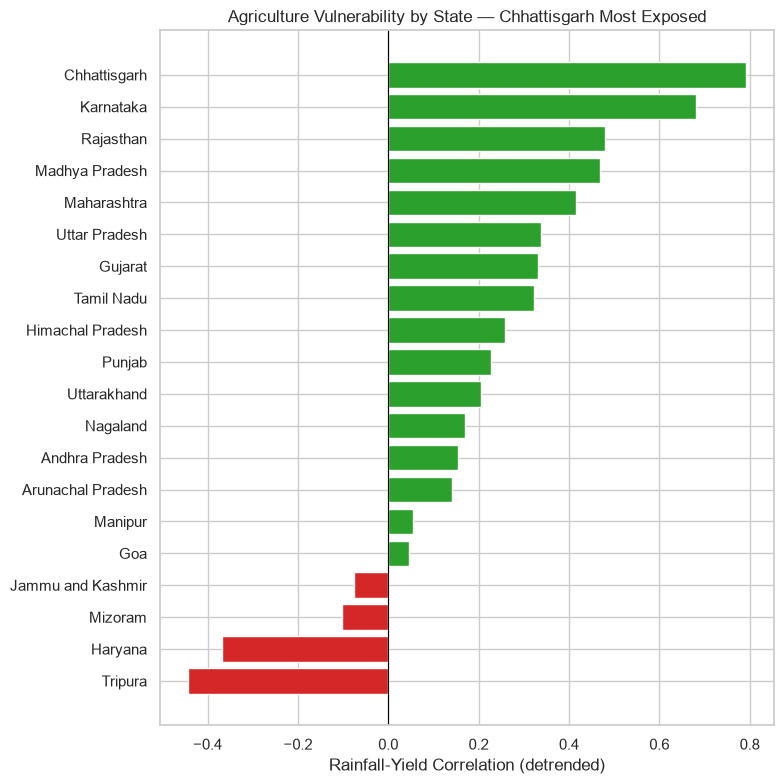

In [34]:
plot_agri = agriculture_vulnerability.sort_values("rain_yield_corr")
agri_colors = ["#d62728" if v < 0 else "#2ca02c" for v in plot_agri["rain_yield_corr"]]

plt.figure(figsize=(8, 8))
plt.barh(plot_agri["state"], plot_agri["rain_yield_corr"], color=agri_colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Rainfall-Yield Correlation (detrended)")
plt.title("Agriculture Vulnerability by State — Chhattisgarh Most Exposed")
plt.tight_layout()
plt.show()


## Downstream Impact - Infrastructure and Human Vulnerability

In [35]:
census = pd.read_csv("../data/raw/india_census_2011_districts.csv")

CENSUS_STATE_TO_SUBDIVISIONS = {
    'JAMMU AND KASHMIR': ['Jammu & Kashmir'], 'HIMACHAL PRADESH': ['Himachal Pradesh'],
    'PUNJAB': ['Punjab'], 'CHANDIGARH': ['Haryana Delhi & Chandigarh'],
    'UTTARAKHAND': ['Uttarakhand'], 'HARYANA': ['Haryana Delhi & Chandigarh'],
    'NCT OF DELHI': ['Haryana Delhi & Chandigarh'], 'RAJASTHAN': ['East Rajasthan', 'West Rajasthan'],
    'UTTAR PRADESH': ['East Uttar Pradesh', 'West Uttar Pradesh'], 'BIHAR': ['Bihar'],
    'SIKKIM': ['Sub Himalayan West Bengal & Sikkim'], 'ARUNACHAL PRADESH': ['Arunachal Pradesh'],
    'NAGALAND': ['Naga Mani Mizo Tripura'], 'MANIPUR': ['Naga Mani Mizo Tripura'],
    'MIZORAM': ['Naga Mani Mizo Tripura'], 'TRIPURA': ['Naga Mani Mizo Tripura'],
    'MEGHALAYA': ['Assam & Meghalaya'], 'ASSAM': ['Assam & Meghalaya'],
    'WEST BENGAL': ['Gangetic West Bengal', 'Sub Himalayan West Bengal & Sikkim'],
    'JHARKHAND': ['Jharkhand'], 'ORISSA': ['Orissa'], 'CHHATTISGARH': ['Chhattisgarh'],
    'MADHYA PRADESH': ['East Madhya Pradesh', 'West Madhya Pradesh'],
    'GUJARAT': ['Gujarat Region', 'Saurashtra & Kutch'],
    'DAMAN AND DIU': ['Gujarat Region'], 'DADRA AND NAGAR HAVELI': ['Gujarat Region'],
    'MAHARASHTRA': ['Konkan & Goa', 'Madhya Maharashtra', 'Matathwada', 'Vidarbha'],
    'ANDHRA PRADESH': ['Coastal Andhra Pradesh', 'Rayalseema'],
    'KARNATAKA': ['Coastal Karnataka', 'North Interior Karnataka', 'South Interior Karnataka'],
    'GOA': ['Konkan & Goa'], 'LAKSHADWEEP': ['Lakshadweep'], 'KERALA': ['Kerala'],
    'TAMIL NADU': ['Tamil Nadu'], 'PONDICHERRY': ['Tamil Nadu'],
    'ANDAMAN AND NICOBAR ISLANDS': ['Andaman & Nicobar Islands'], 'TELANGANA': ['Telangana'],
}

haz = regional_df.groupby("SUBDIVISION")["risk_flag"].apply(
    lambda x: pd.Series({
        "pct_deficient_years": (x.str.contains("Deficient")).mean() * 100,
        "pct_excess_years": (x.str.contains("Excess")).mean() * 100,
    })
).unstack()

def state_hazard(state_name):
    subs = CENSUS_STATE_TO_SUBDIVISIONS.get(state_name.upper())
    if not subs:
        return None, None
    rows = haz.loc[haz.index.intersection(subs)]
    if rows.empty:
        return None, None
    return rows["pct_deficient_years"].mean(), rows["pct_excess_years"].mean()

hazard_pairs = census["State name"].apply(state_hazard)
census["pct_deficient_years"] = [h[0] for h in hazard_pairs]
census["pct_excess_years"] = [h[1] for h in hazard_pairs]
census = census.dropna(subset=["pct_deficient_years"]).copy()

census["agri_worker_pct"] = (census["Cultivator_Workers"] + census["Agricultural_Workers"]) / census["Workers"].replace(0, np.nan) * 100
flood_norm = census["pct_excess_years"] / census["pct_excess_years"].max()
drought_norm = census["pct_deficient_years"] / census["pct_deficient_years"].max()
exposure_norm = census["Population"] / census["Population"].max()
vulnerability_norm = census["agri_worker_pct"] / 100
census["human_vulnerability_index"] = (flood_norm + drought_norm) / 2 * exposure_norm * vulnerability_norm

human_vulnerability_index = census.nlargest(15, "human_vulnerability_index")[
    ["District name", "State name", "Population", "agri_worker_pct", "pct_deficient_years", "pct_excess_years", "human_vulnerability_index"]
]
census.to_csv("../data/processed/human_vulnerability_index.csv", index=False)
human_vulnerability_index


,District name,State name,Population,agri_worker_pct,pct_deficient_years,pct_excess_years,human_vulnerability_index
515,Nashik,MAHARASHTRA,6107187,61.433641,28.308824,33.823529,0.208261
343,Paschim Medinipur,WEST BENGAL,5913457,66.853834,30.147059,30.147059,0.207743
544,East Godavari,ANDHRA PRADESH,5154296,61.253505,33.823529,35.294118,0.191327
547,Guntur,ANDHRA PRADESH,4887813,64.254349,33.823529,35.294118,0.190324
334,Barddhaman,WEST BENGAL,7717563,45.181539,30.147059,30.147059,0.183231
521,Ahmadnagar,MAHARASHTRA,4543159,71.308452,28.308824,33.823529,0.179829
153,Sitapur,UTTAR PRADESH,4483992,73.432415,34.558824,29.411765,0.179401
537,Mahbubnagar,ANDHRA PRADESH,4053028,72.039629,33.823529,35.294118,0.176940
332,Murshidabad,WEST BENGAL,7103807,47.236059,30.147059,30.147059,0.176329
154,Hardoi,UTTAR PRADESH,4092845,76.094321,34.558824,29.411765,0.169688


In [36]:
census["dilapidated_pct"] = census["Condition_of_occupied_census_houses_Dilapidated_Households"] / census["Households"].replace(0, np.nan) * 100
census["rural_pct"] = census["Rural_Households"] / census["Households"].replace(0, np.nan) * 100
census["infra_flood_risk"] = flood_norm.loc[census.index] * (census["dilapidated_pct"] / 100) * exposure_norm.loc[census.index]

infrastructure_risk = census.nlargest(15, "infra_flood_risk")[
    ["District name", "State name", "Population", "dilapidated_pct", "rural_pct", "pct_excess_years", "infra_flood_risk"]
]
census.to_csv("../data/processed/infrastructure_risk.csv", index=False)
print("Top 15 infrastructure-at-risk districts (flood-prone x housing fragility x population):")
infrastructure_risk


Top 15 infrastructure-at-risk districts (flood-prone x housing fragility x population):


,District name,State name,Population,dilapidated_pct,rural_pct,pct_excess_years,infra_flood_risk
332,Murshidabad,WEST BENGAL,7103807,13.535785,81.052612,30.147059,0.064809
342,South Twenty Four Parganas,WEST BENGAL,8161961,11.357048,71.955737,30.147059,0.062477
336,North Twenty Four Parganas,WEST BENGAL,10009781,9.226551,42.297229,30.147059,0.062248
344,Purba Medinipur,WEST BENGAL,5095875,13.871394,87.482190,30.147059,0.047643
343,Paschim Medinipur,WEST BENGAL,5913457,10.149721,87.156626,30.147059,0.040453
335,Nadia,WEST BENGAL,5167600,11.234176,69.776825,30.147059,0.039128
334,Barddhaman,WEST BENGAL,7717563,6.330043,61.280798,30.147059,0.032927
333,Birbhum,WEST BENGAL,3502404,12.501644,86.064235,30.147059,0.029512
153,Sitapur,UTTAR PRADESH,4483992,9.943956,88.143704,29.411765,0.029320
327,Jalpaiguri,WEST BENGAL,3872846,11.144351,71.423792,30.147059,0.029090
